## Bonus Exercise - Performance Analysis and Optimization of the Game of Life Code

### Task B.1

#### Formatting

In [2]:
!pylint conway.py

************* Module conway
conway.py:11:31: C0303: Trailing whitespace (trailing-whitespace)
conway.py:24:38: C0303: Trailing whitespace (trailing-whitespace)
conway.py:25:38: C0303: Trailing whitespace (trailing-whitespace)
conway.py:59:28: C0303: Trailing whitespace (trailing-whitespace)
conway.py:64:70: C0303: Trailing whitespace (trailing-whitespace)
conway.py:66:62: C0303: Trailing whitespace (trailing-whitespace)
conway.py:67:62: C0303: Trailing whitespace (trailing-whitespace)
conway.py:68:74: C0303: Trailing whitespace (trailing-whitespace)
conway.py:95:0: C0303: Trailing whitespace (trailing-whitespace)
conway.py:100:0: C0303: Trailing whitespace (trailing-whitespace)
conway.py:127:18: C0303: Trailing whitespace (trailing-whitespace)
conway.py:80:0: R1707: Disallow trailing comma tuple (trailing-comma-tuple)
conway.py:9:0: C0410: Multiple imports on one line (sys, argparse) (multiple-imports)
conway.py:12:0: R0402: Use 'from matplotlib import animation' instead (consider-usin

In [3]:
!black conway.py

reformatted conway.py

All done! ✨ 🍰 ✨
1 file reformatted.


In [4]:
!pylint conway.py

************* Module conway
conway.py:9:0: C0410: Multiple imports on one line (sys, argparse) (multiple-imports)
conway.py:12:0: R0402: Use 'from matplotlib import animation' instead (consider-using-from-import)
conway.py:19:0: C0103: Function name "randomGrid" doesn't conform to snake_case naming style (invalid-name)
conway.py:19:15: C0103: Argument name "N" doesn't conform to snake_case naming style (invalid-name)
conway.py:24:0: C0103: Function name "addGlider" doesn't conform to snake_case naming style (invalid-name)
conway.py:30:0: C0103: Function name "addGosperGliderGun" doesn't conform to snake_case naming style (invalid-name)
conway.py:59:0: C0116: Missing function or method docstring (missing-function-docstring)
conway.py:59:11: C0103: Argument name "frameNum" doesn't conform to snake_case naming style (invalid-name)
conway.py:59:32: C0103: Argument name "N" doesn't conform to snake_case naming style (invalid-name)
conway.py:62:4: C0103: Variable name "newGrid" doesn't confo

#### Documentation

In [41]:
!mkdir -p docs
!sphinx-quickstart docs -q -p "Bonus" -a "Pavel & Ermia" -v "0" --ext-autodoc


Finished: An initial directory structure has been created.

You should now populate your master file /home/pavel/IdeaProjects/DD2358/Ass2/docs/index.rst and create other documentation
source files. Use the Makefile to build the docs, like so:
   make builder
where "builder" is one of the supported builders, e.g. html, latex or linkcheck.



Update `conf.py` with
```
import os
import sys
sys.path.insert(0, os.path.abspath('../..'))
```
to handle being in a separate directory.

In [42]:
!echo "\nimport os\nimport sys\nsys.path.insert(0, os.path.abspath('../..'))" >> docs/conf.py

Tell sphinx to autodoc our `conway.py`

In [43]:
!echo "Conway Module\n=============\n\n.. automodule:: conway\n    :members:\n    :undoc-members:\n    :show-inheritance:" > docs/conway.rst

In [47]:
!echo "   conway" >> docs/index.rst

In [50]:
!make -C docs html

make: Entering directory '/home/pavel/IdeaProjects/DD2358/Ass2/docs'
Running Sphinx v9.1.0
loading translations [en]... done
loading pickled environment... done
building [mo]: targets for 0 po files that are out of date
writing output... 
building [html]: targets for 1 source files that are out of date
updating environment: 0 added, 1 changed, 0 removed
reading sources... [100%] index
looking for now-outdated files... none found
pickling environment... done
checking consistency... done
preparing documents... done
copying assets... 
copying static files... 
Writing evaluated template result to /home/pavel/IdeaProjects/DD2358/Ass2/docs/_build/html/_static/basic.css
Writing evaluated template result to /home/pavel/IdeaProjects/DD2358/Ass2/docs/_build/html/_static/documentation_options.js
Writing evaluated template result to /home/pavel/IdeaProjects/DD2358/Ass2/docs/_build/html/_static/language_data.js
Writing evaluated template result to /home/pavel/IdeaProjects/DD2358/Ass2/docs/_build/ht

In [51]:
from IPython.display import HTML, display

display(HTML(filename="docs/_build/html/conway.html"))

### Task B.2

From this point on part the source code was modified to disable the animation and make benchmarking easier.

In [53]:
# %load benchmark.py
import conway
import timeit
import matplotlib.pyplot as plt

grid_sizes = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300]

time = []
for size in grid_sizes:
    t1 = timeit.default_timer()
    conway.main(size)
    t2 = timeit.default_timer()
    time.append((t2 - t1))

plt.figure(figsize=(8, 5))
plt.plot(grid_sizes, time, marker='o')
plt.xlabel("Grid size")
plt.ylabel("Execution time (s)")
plt.title(f"Benchmark: conway.py (100 iterations)")
plt.grid(True)
plt.savefig("benchmark.png", dpi=300)
plt.show()

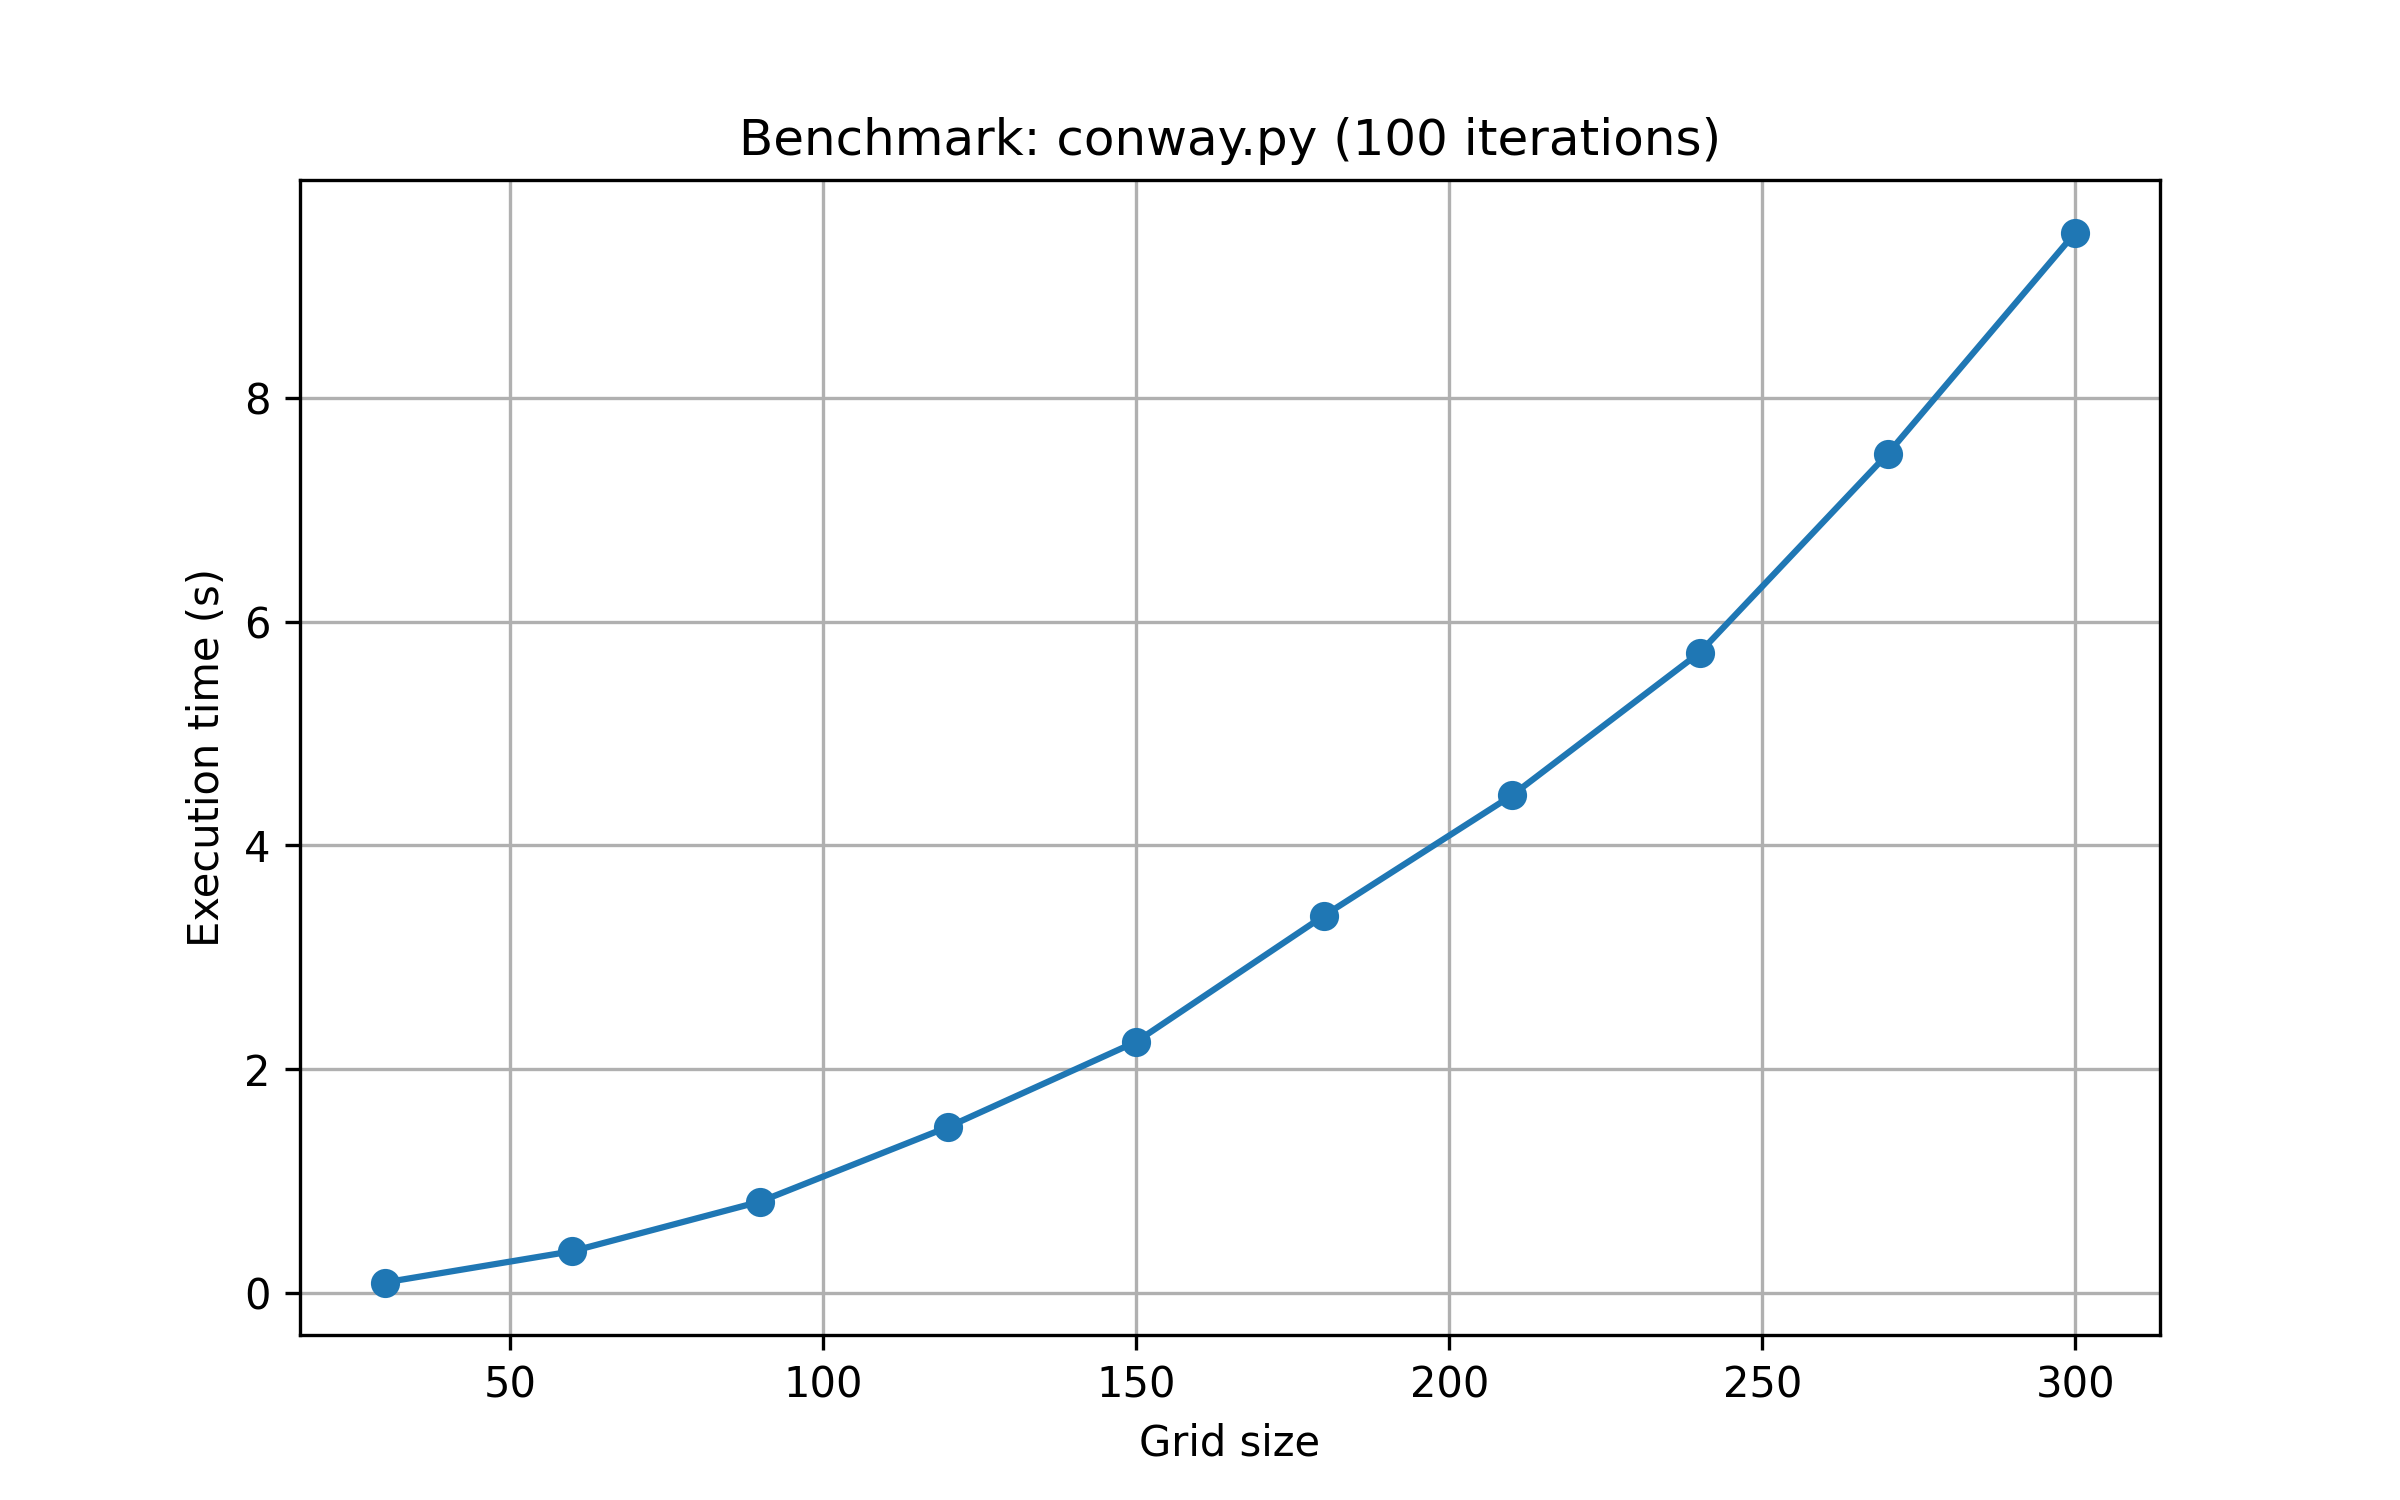

In [54]:
from IPython.display import Image
Image("benchmark.png")

As can be seen the growth is quadratic as is the grid size $N^2$.

### Task B.3

In [55]:
!python -m cProfile -o p.stats conway.py

In [56]:
import pstats
stats = pstats.Stats("p.stats")
stats.sort_stats("cumulative")
stats.print_stats()

Fri Feb 13 21:06:34 2026    p.stats

         1219891 function calls (1202463 primitive calls) in 1.616 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    339/1    0.002    0.000    1.617    1.617 {built-in method builtins.exec}
        1    0.000    0.000    1.617    1.617 conway.py:1(<module>)
        1    0.000    0.000    1.097    1.097 conway.py:95(main)
      100    1.091    0.011    1.091    0.011 conway.py:59(update)
    390/5    0.003    0.000    0.524    0.105 <frozen importlib._bootstrap>:1349(_find_and_load)
    387/5    0.001    0.000    0.524    0.105 <frozen importlib._bootstrap>:1304(_find_and_load_unlocked)
    372/6    0.001    0.000    0.524    0.087 <frozen importlib._bootstrap>:911(_load_unlocked)
    324/6    0.001    0.000    0.523    0.087 <frozen importlib._bootstrap_external>:989(exec_module)
   887/11    0.002    0.000    0.522    0.047 <frozen importlib._bootstrap>:480(_call_with_frames_remove

Most of the time is spent in the `update` function so gonna focus attention there.

In [60]:
!python -m kernprof -l -v conway.py

Wrote profile results to 'conway.py.lprof'
Timer unit: 1e-06 s

Total time: 7.59332 s
File: conway.py
Function: update at line 58

Line #      Hits         Time  Per Hit   % Time  Line Contents
    58                                           @profile
    59                                           def update(frameNum, img, grid, N):
    60                                               # copy grid since we require 8 neighbors for calculation
    61                                               # and we go line by line
    62       100        491.2      4.9      0.0      newGrid = grid.copy()
    63     10100       2758.5      0.3      0.0      for i in range(N):
    64   1010000     276403.1      0.3      3.6          for j in range(N):
    65                                                       # compute 8-neghbor sum
    66                                                       # using toroidal boundary conditions - x and y wrap around
    67                                         

Calculating the neighbor sum takes the majority of the time.

### Task B.4

By applying vectorization, using the `roll` function, we can take the neighboring sum outside of the loop and gain performance that way. Next step would be to vectorize the creation of the `newGrid` and apply inplace operations.

In [ ]:
def update_old(frameNum, img, grid, N):
    #...
    newGrid = grid.copy()
    for i in range(N):
        for j in range(N):
            total = int(
                (
                        grid[i, (j - 1) % N]
                        + grid[i, (j + 1) % N]
                        + grid[(i - 1) % N, j]
                        + grid[(i + 1) % N, j]
                        + grid[(i - 1) % N, (j - 1) % N]
                        + grid[(i - 1) % N, (j + 1) % N]
                        + grid[(i + 1) % N, (j - 1) % N]
                        + grid[(i + 1) % N, (j + 1) % N]
                )
                / 255
            )
    #...

In [ ]:
import numpy as np
def update_new(frameNum, img, grid, N):
    #...
    top = np.roll(grid, 1, 0)
    bottom = np.roll(grid, -1, 0)

    total2 = (top + bottom
              + np.roll(grid, 1, 1)
              + np.roll(grid, -1, 1)
              + np.roll(top, 1, 1)
              + np.roll(top, -1, 1)
              + np.roll(bottom, 1, 1)
              + np.roll(bottom, -1, 1)
              ) / 255

    for i in range(N):
        for j in range(N):
            total = total2[i][j]
    #...

In [5]:
!python -m cProfile conway2.py

         1215215 function calls (1197921 primitive calls) in 0.565 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       37    0.001    0.000    0.765    0.021 __init__.py:1(<module>)
    335/1    0.002    0.000    0.566    0.566 {built-in method builtins.exec}
        1    0.000    0.000    0.566    0.566 conway2.py:1(<module>)
    377/4    0.001    0.000    0.566    0.142 <frozen importlib._bootstrap>:1349(_find_and_load)
    374/4    0.001    0.000    0.566    0.141 <frozen importlib._bootstrap>:1304(_find_and_load_unlocked)
    359/5    0.001    0.000    0.565    0.113 <frozen importlib._bootstrap>:911(_load_unlocked)
    320/5    0.001    0.000    0.565    0.113 <frozen importlib._bootstrap_external>:989(exec_module)
    850/9    0.000    0.000    0.564    0.063 <frozen importlib._bootstrap>:480(_call_with_frames_removed)
   459/12    0.000    0.000    0.531    0.044 {built-in method builtins.__import__}
   366/74  

In [4]:
!python -m kernprof -l -v conway2.py

Wrote profile results to 'conway2.py.lprof'
Timer unit: 1e-06 s

Total time: 1.4806 s
File: conway2.py
Function: update at line 59

Line #      Hits         Time  Per Hit   % Time  Line Contents
    59                                           @profile
    60                                           def update(frameNum, img, grid, N):
    61                                               # copy grid since we require 8 neighbors for calculation
    62                                               # and we go line by line
    63       100        433.9      4.3      0.0      newGrid = grid.copy()
    64                                           
    65       100       4443.1     44.4      0.3      top = np.roll(grid, 1, 0)
    66       100       2458.1     24.6      0.2      bottom = np.roll(grid, -1, 0)
    67                                           
    68       800       4572.3      5.7      0.3      total2 = (top + bottom
    69       100       2453.9     24.5      0.2              

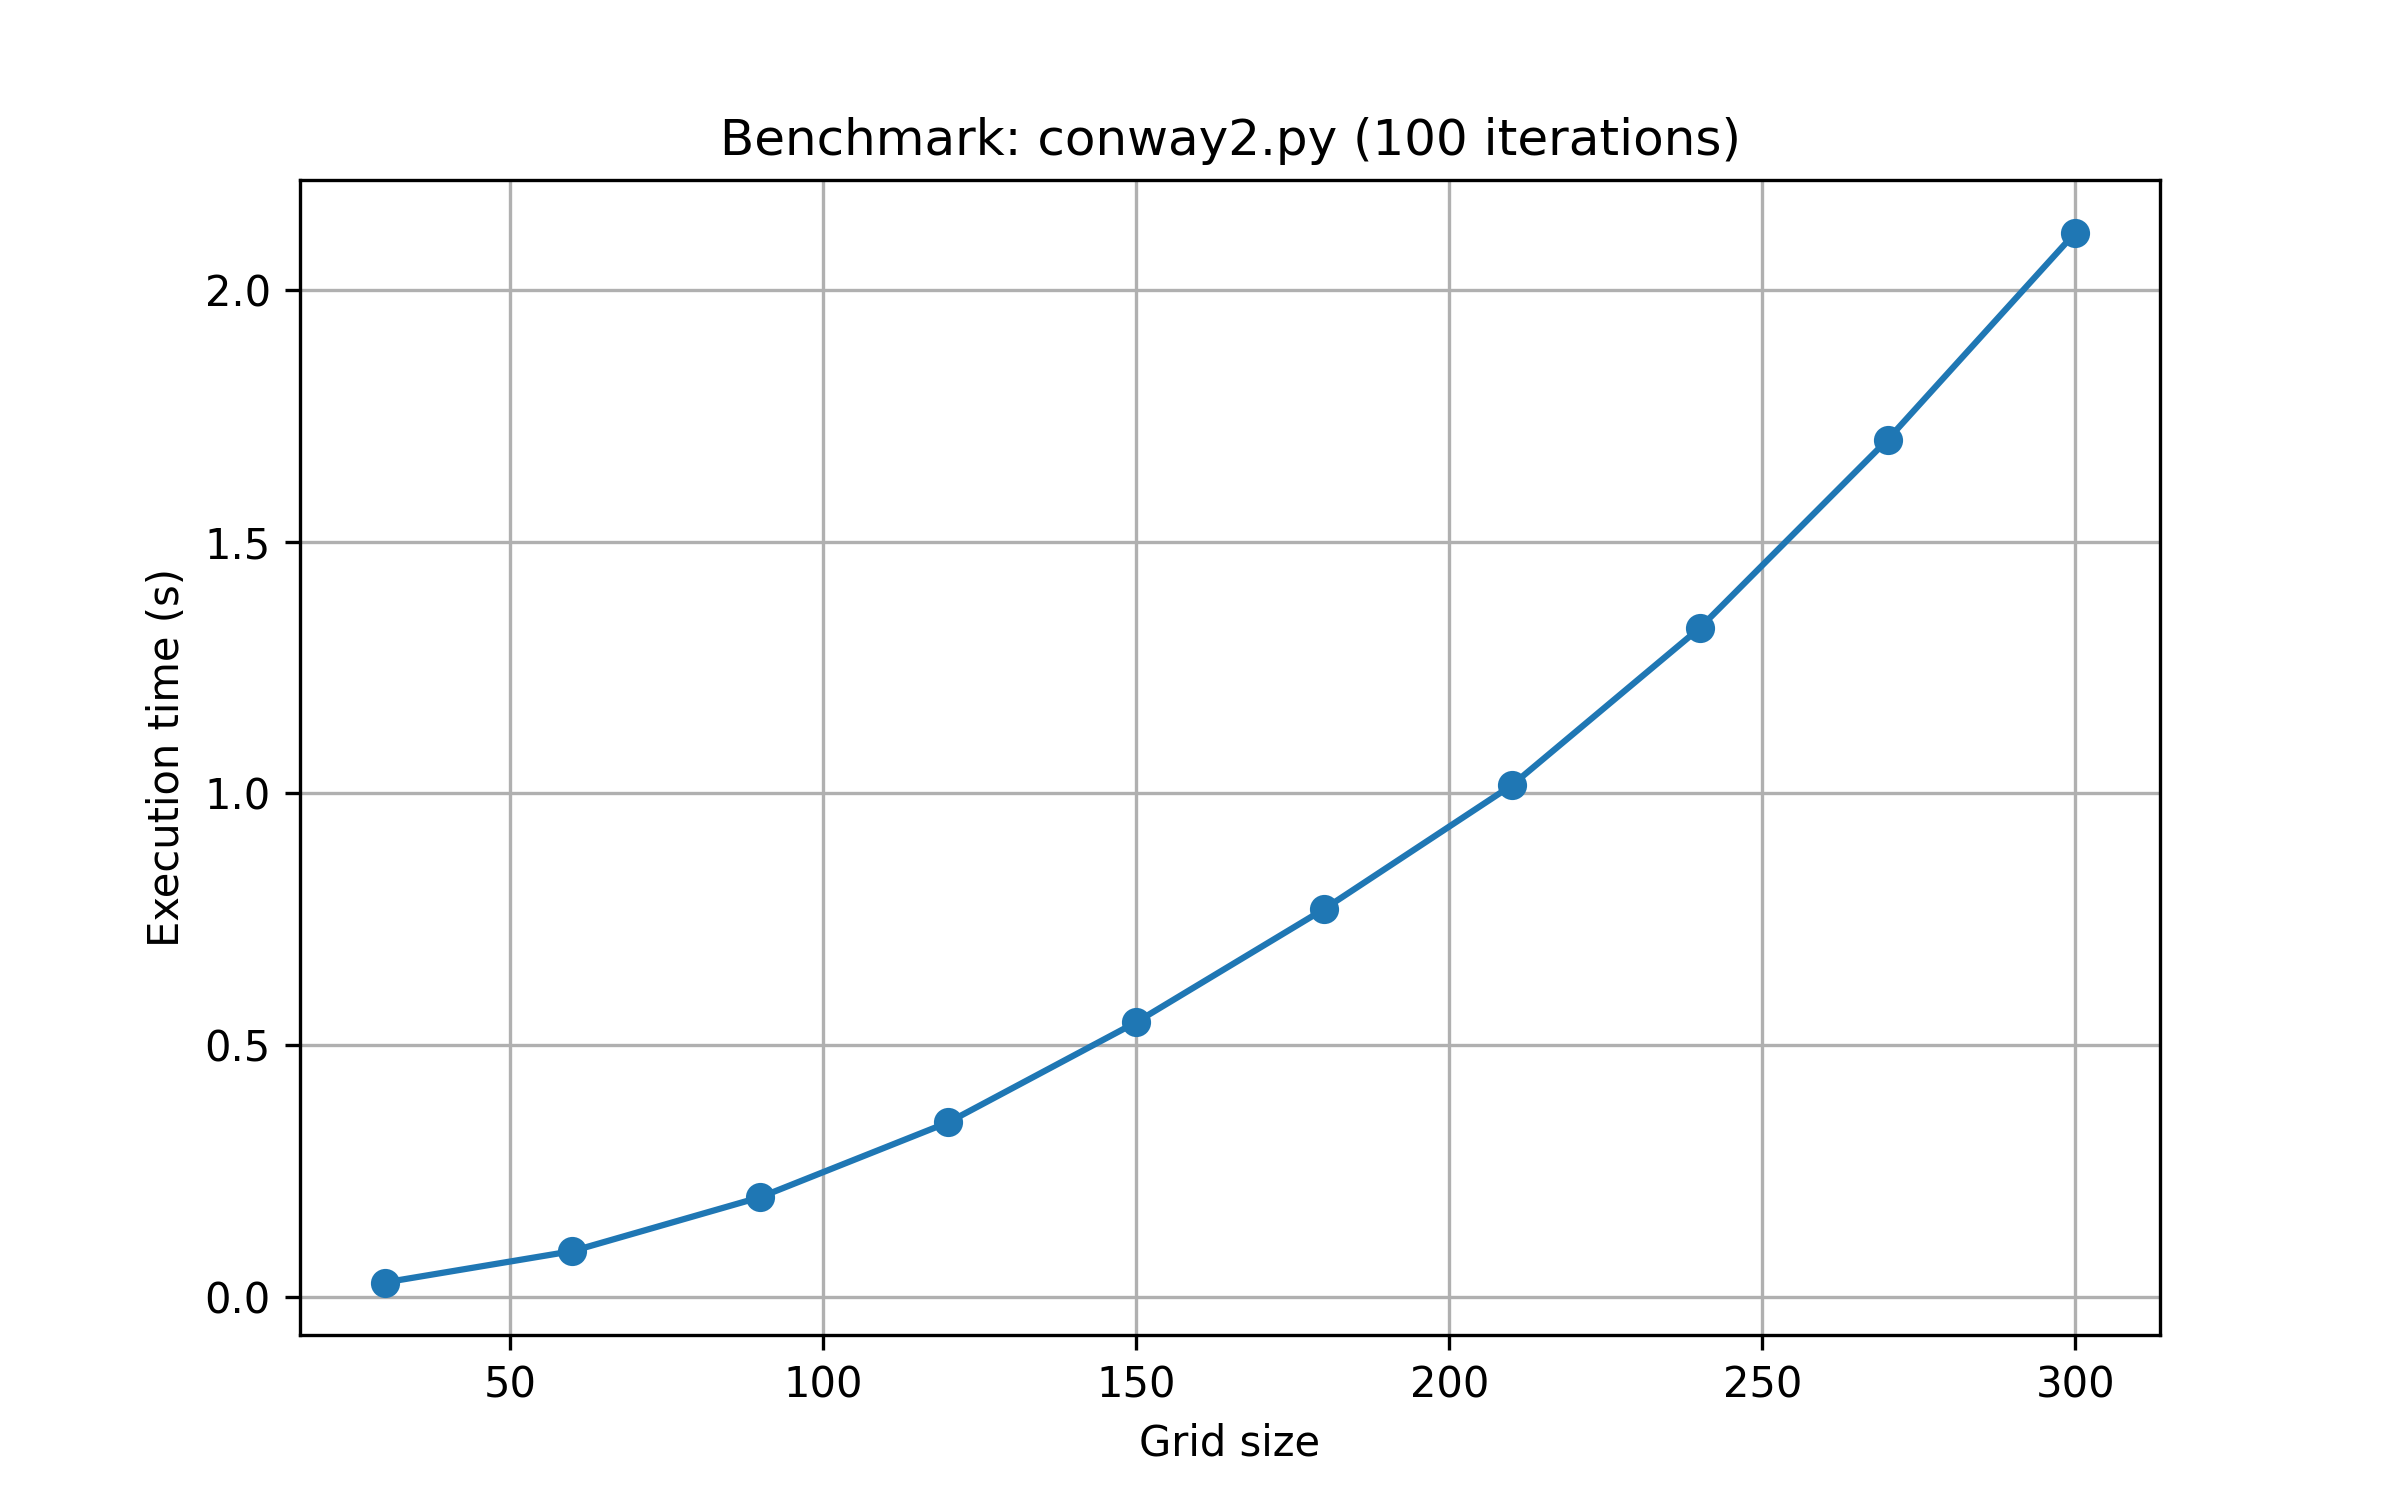

In [6]:
from IPython.display import Image
Image("benchmark2.png")

As can be seen the optimization was a success, the correctness was tested with `assert` against the original implementation. The performance gains are significant as now we can run a 300x300 grind in about the same time it took for a 150x150 grid with the old implementation.